# Mechanical testing of porous media

***

Phase distributions generated using tostada can be used for simulating stress-strain response using an in-built Volume Compensated Lattice Particle Method code. Essentially, it treates each pixel (solid) as a particle and determines local and non-local forces on each due to its neighbouring particles. The interaction between them is described through spring forces with spring's constant being analytically related to the Young's modulus and Poisson ratio. **Please note, currently, this is only available for 2D systems.** 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost

GPU not available : cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version
GPU not available : cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version
GPU not available : cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version


In [2]:
process = tost.Pointprocess(6,0.28,0.5)
points = process.RandomSequentialAdsorption(sdev_histo=0.06)
#points = process.rect_lattice()
phase = points.Phaseobject(dx=0.02) # remember to not have periodic boundaries here since load will be in the xy-plane
print (phase.volumefraction)

Estimated particles to be deposited=144 with mean inter-particle distance=0.5
number of experiments:2190500): |------------------------------| 2.2% Current FF=3.972 of 4.000
0.8013333333333333


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

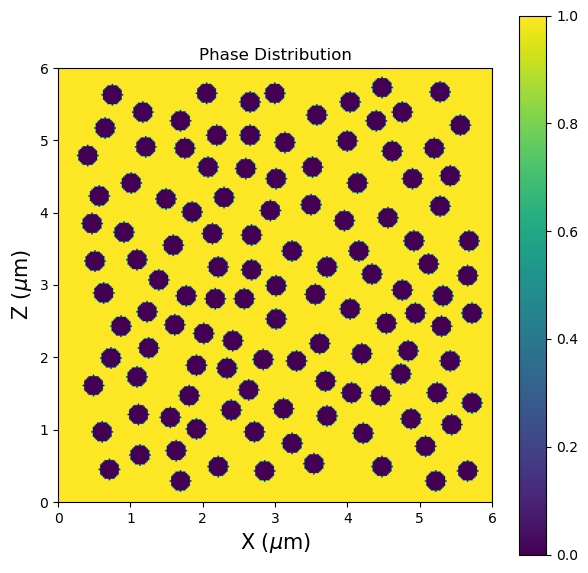

In [3]:
fig = tost.Visualize(phase)
fig.plot_distribution()
#plt.imshow(phase.image)

Now, we can import the Mechanical simulation module as well as the material. While one can specify a custom material with any Young's modulus, Poisson ratio and mass density, we use a pre-loaded material in the materials module. Here, we use Anodized Aluminium Oxide as the material.

In [4]:
from tostada.physics import Lattice_Particle_Method_gpu as lpm
from tostada.util.materials import AAO

In [5]:
print (np.array([AAO.youngs_modulus]), AAO.poisson_ratio)

[3.e+11] 0.33


Initialize the mechanical solver with the `PhaseDistribution` object and the material. **Note, this can run for over a minute when the number of pixels are greater than $500^2$ as it calculates all the neighbouring elements at rest (without applied force).**

In [6]:
system = lpm.LatticeParticleMethod(phase,Material=AAO)

Now, we need two things to start the simulation.
1) Boundary conditions: This will decide which boundaries will remain fixed/clamped throughout the simulation. 
2) Applied forces: This will decide which boundaries will have applied force and in which direction.

For this demonstration, we will clamp the system on it's left boundary and apply a compressive force on it's right boundary (force along negative x direction).

In [7]:
particle_roi = np.full(system.positions.shape[0],True)
particle_roi[np.where((system.positions[:,0]==0))[0]]=False #important; do not displace the left edge

In [8]:
force_roix = system.boundary_condition(edge='right',value=-0.005/system.image.shape[0]) #x-component of applied force
force_roiy = system.boundary_condition(edge='right',value=0) #y-component of applied force
Force_ext = np.c_[force_roix,force_roiy] 

The system is now completely defined to run the simulation. We can run it using `run_sim()` function. Since LPM is a time-domain method, the system will slowly get displaced over time (non-zero velocity) with a constant applied force. Due to the internal force resisting the applied force, this method sets the velocities to zero every time kinetic energy of current time step is lesser than or equal to that of current time step. Eventually, the system reaches a steady-state solution that is directly comparable to a frequency-domain COMSOL or other Finite-Element-Method solver **in the linear elastic regime**.
In a future release, there will be a functionality for crack-initiation and crack-propagation for which a constant displacement (or equivalently, a growing force over time) can be applied.

In [9]:
_sysmat = system.run_sim(particle_roi,Force_ext,
                         dt = system.dtc*0.6, # sets the time-stepping 
                         at_every=100, #how frequently should the post-processing quantities be saved
                         tolerance=1e-3, # tolerance for Kinetic Energy ratio of current versus previous time step. If reached, the simulation terminates. 
                         num_steps=2000
                         )

/mnt/c/Users/pd/Downloads/tostada_project/src/tostada/physics/Lattice_Particle_Method_gpu.py:141: RuntimeWarning: invalid value encountered in divide
  unitvec = cp.nan_to_num(_Dnew / Dnew[:, :, None])


current time step=100
current time step=200
current time step=300
current time step=400
current time step=500
current time step=600
current time step=700
current KE= 8.053189999742578e-17
Ratio= 0.9999885513933537
velocities set to zero at t= 701
current time step=800
current time step=900
current KE= 2.752600167695529e-18
Ratio= 0.034179854869274676
velocities set to zero at t= 982
current time step=1000
current time step=1100
current KE= 7.437691981413489e-19
Ratio= 0.009235603320474722
velocities set to zero at t= 1177
current time step=1200
current time step=1300
current KE= 1.886325088142035e-19
Ratio= 0.0023423059587671345
velocities set to zero at t= 1325
current time step=1400
current KE= 5.254891226585038e-20
Ratio= 0.0006525154709587615
velocities set to zero at t= 1428
Simulation converged


##### The simulation now saves several quantities at `at_every` time steps. Here, we visualize the Von Mises stress in the system at the converged time step.

<Axes: title={'center': 'Stress: Von Mises, time=1.6e-09s'}>

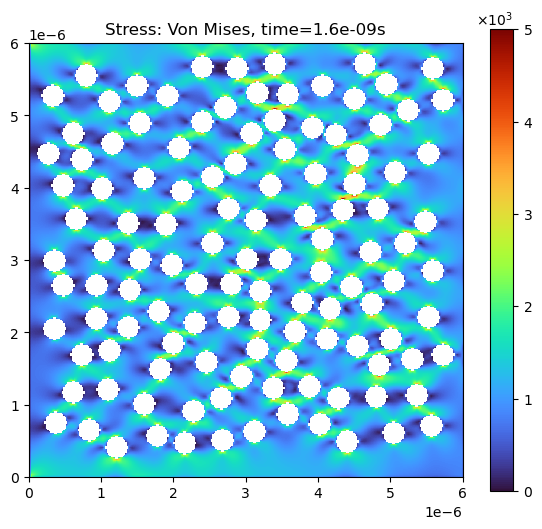

In [11]:
system.plot_stress(ind=-1, #last time step
                   mode='Von Mises', # other available options : sigma_xx, sigma_xy, sigma_yy, principal forces 1 and 2.
                   vmax=5e3)

#### There is also a functionality to evaluate global properties of the system like:
##### 1) Stress concentration ($max(\sigma_{vm})/std(\sigma_{vm})$) where $\sigma_{vm}$ is the Von Mises stress
##### 2) Effective Poisson ratio $\nu_{eff}$
##### 3) Effective Young's modulus along (xx, xy, yy) direction. 

In [34]:
effective_ = np.array(system.effective_quantities())
print ( effective_)

[ 7.60203580e+00  3.25211659e-01  1.61171403e+11  4.12764694e+10
 -1.48788489e+10]


In [36]:
effective_[2]/system.Y

np.float64(0.5372380085705821)

#### We can also use a different parameterization for creating the porous media from our original `PointDistribution`. The other available option currently is through a Voronoi network. Refer to `points_to_pores_2.ipynb` for further details. 

#### For a meaningful comparison, we tune the `rad` parameter until we get the same porosity as the previous case. Since the default structure obtained this way is periodic (pores at the boundaries), we can mask the boundaries by a constant padding. This will ensure that the applied forces here are the same as the circular pores case. This can be done with `mode` option.

Masking boundaries by 0.08 microns
Volume fraction of generated phase = 0.7962444444444444
0.7962444444444444


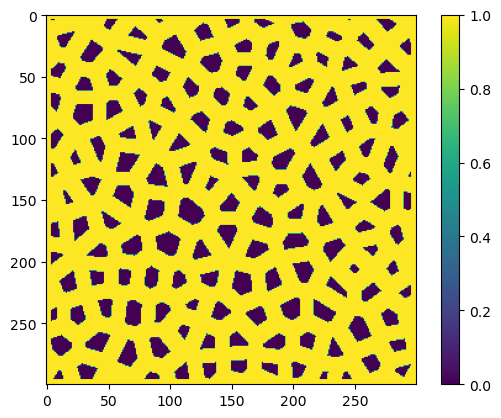

In [ ]:
phase = points.Phaseobject_voronoi(resolution=0.02,rad=11,mode='padding') 

print ( np.mean(phase.image))
plt.imshow(phase.image)
plt.colorbar()

Let's re-run the simulation now

In [ ]:
system = lpm.LatticeParticleMethod(phase,Material=AAO)
particle_roi = np.full(system.positions.shape[0],True)
particle_roi[np.where((system.positions[:,0]==0))[0]]=False #important
force_roix = system.boundary_condition(edge='right',value=-0.005/system.image.shape[0])

force_roiy = system.boundary_condition(edge='right',value=0)
Force_ext = np.c_[force_roix,force_roiy]

_sysmat = system.run_sim(particle_roi,Force_ext,
                         dt = system.dtc*0.6,at_every=100,
                         tolerance=1e-3,num_steps=2000)

current time step=100
current time step=200
current time step=300
current time step=400
current time step=500
current time step=600
current time step=700
current KE= 8.564400363446027e-17
Ratio= 0.99997517352781
velocities set to zero at t= 719
current time step=800
current time step=900
current KE= 2.359419217234979e-18
Ratio= 0.02754846271841115
velocities set to zero at t= 971
current time step=1000
current time step=1100
current KE= 8.383259451918233e-19
Ratio= 0.009788252498027228
velocities set to zero at t= 1110
current KE= 2.035128747940242e-19
Ratio= 0.0023762063151075426
velocities set to zero at t= 1177
current time step=1200
current KE= 3.7496783250850196e-20
Ratio= 0.0004378105967353041
velocities set to zero at t= 1224
Simulation converged


<Axes: title={'center': 'Stress: von-mises, time=1.4e-09s'}>

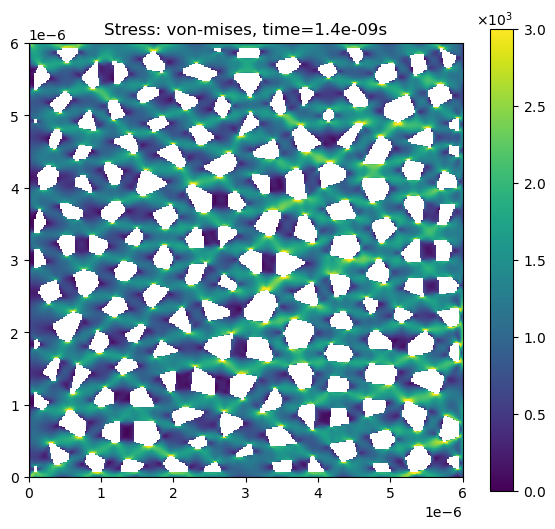

In [44]:
system.plot_stress(ind=-1,mode='von-mises',vmax=3e3,cmap='viridis')

In [41]:
effective_ = np.array(system.effective_quantities())
print ( effective_)

[ 9.21616308e+00  3.20127599e-01  1.50827836e+11  5.34441954e+11
 -1.25741165e+10]


In [43]:
effective_[2]/system.Y

np.float64(0.5027594524972248)

It can be seen that the effective Young's modulus and the Poisson ratio are comparable in both the cases, if not exactly equal. This is because for small porosities ($< 0.4$), the geometrical details are less important than the porosity. 